Course link: https://www.youtube.com/watch?v=a4HBKEda_F8

# 1. Introdcution
The course is structured in two parts: 
1. Essential Elasticsearch fundamentals: index management, document storage, text analysis, pipeline creation, search functionality, and advanced features like semantic search and embeddings.

2. A practical section where you'll build a real-world website using Elasticsearch as a search engine, working with the Astronomy Picture of the Day (APOD) dataset to implement features such as data cleaning pipelines, tokenization, pagination, and aggregations.


# 2. Installation

1. Make sure docker is installed: https://www.docker.com/
2. Go to the following site and copy the command onto cmd: https://www.elastic.co/search-labs/tutorials/install-elasticsearch/docker


* Linux:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch \
    -e "discovery.type=single-node" \
    -e "xpack.security.enabled=false" \
    -e "xpack.license.self_generated.type=trial" \
    -v "elasticsearch-data:/usr/share/elasticsearch/data" \
    docker.elastic.co/elasticsearch/elasticsearch:8.15.0


* Windows:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch -e "discovery.type=single-node" -e "xpack.security.enabled=false" -e "xpack.license self_generated.type=trial" -v "elasticsearch-data:/usr/share/elasticsearch/data" docker.elastic.co/elasticsearch/elasticsearch:8.15.0




check your container is up and running in http://localhost:9200.

* To stop and remove it, run this in cmd: 
  
  **docker stop elasticsearch**
   
  **docker rm elasticsearch**
* To stop it but keep it (so you can restart it later): **docker stop elasticsearch**
  Then restart it with: **docker start elasticsearch**
* Check status anytime with: **docker ps -a**
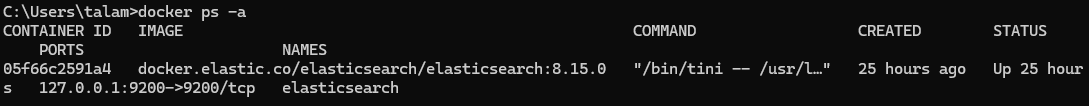

In [1]:
# run this cell to install the necessary dependencies
%pip install "elasticsearch<9"

## Imports

In [ ]:
# all imports of the notebook
from elasticsearch import Elasticsearch
from pprint import pprint
import base64

# 3. Create an Index

## Definitions:
* **Index**: collection of documents that share similar characteristics.
    Can be compared to datasbase in a relational database (i.e. SQL) and optimized for searching large volumes of textual, numeric and structured data.
* **Shard**: a partition of an index. The index is divided into multiple shards, and each shard stores a subset of the documents. This allows data to be distributed across nodes and queries to be executed in parallel.
    Elasticsearch knows how to reconstruct the documents to find the information we need.

* **Replica**: a copy of the data (i.e., replica=1 means each shard is duplicated once). Each replica shard has the same data and structure as its primary shard. Replicas are used for system resilience (fault tolerance) and for improving search performance by allowing parallel searches.

In [2]:
# Connect to Elasticsearch
es = Elasticsearch("http://localhost:9200")

# Check if the connection is successful
if es.ping():
    print("Connected to Elasticsearch!")

    # Get and print cluster information
    info = es.info()
    pprint(info)
else:
    print("Connection failed.")

Connected to Elasticsearch!
ObjectApiResponse({'name': 'bf7e11a5c071', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'Yn5zjAt7TUOntAMcWpLSeg', 'version': {'number': '8.15.0', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '1a77947f34deddb41af25e6f0ddb8e830159c179', 'build_date': '2024-08-05T10:05:34.233336849Z', 'build_snapshot': False, 'lucene_version': '9.11.1', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'})


In [ ]:
# Helper functions for the whole notebook

def create_dummy_index(index_name):
    # dummy index and documents for the next section
    if es.indices.exists(index=index_name):
        es.indices.delete(index=index_name)
        print(f"Index '{index_name}' deleted.")


    es.indices.create(index=index_name, mappings={
        "properties": {
            "field1": {"type": "text"},
            "field2": {"type": "keyword"}
        }
    })

    # creating 3 dummy docs
    docs = [
        {"field1": "This is the first document.", "field2": "A"},
        {"field1": "This is the second document.", "field2": "B"},
        {"field1": "This is the third document.", "field2": "C"}
    ]

    # adding the dummy docs to the index
    for doc in docs:
        response = es.index(index=index_name, body=doc)
        print(f"Document indexed with ID: {response['_id']} and result: {response['result']}")


In [3]:
# deleting the index if it already exists
if es.indices.exists(index="my_index"):
    es.indices.delete(index="my_index")
    print("Index 'my_index' deleted.")

# creating an index
index_name = "my_index"
if not es.indices.exists(index=index_name):
    # create the index + change settings: shards and replicas
    es.indices.create(index=index_name, body={"settings": {"number_of_shards": 3, "number_of_replicas": 2}})

    # print the response + check index settings
    response = es.indices.get(index=index_name)
    pprint(response)
else:    
    print(f"Index '{index_name}' already exists.")
    

Index 'my_index' deleted.
ObjectApiResponse({'my_index': {'aliases': {}, 'mappings': {}, 'settings': {'index': {'routing': {'allocation': {'include': {'_tier_preference': 'data_content'}}}, 'number_of_shards': '3', 'provided_name': 'my_index', 'creation_date': '1773342200874', 'number_of_replicas': '2', 'uuid': 'BP6h1_VAQVSy5lGGlHy_Nw', 'version': {'created': '8512000'}}}}})


# 4. Inserting Documents

## Definitions:
* **Mapping**: the process elasticsearch does in order to automatically detect the types of the fields in the document.

**Note**: manual mappping should be done in the creation of the index and before inserting any documents.
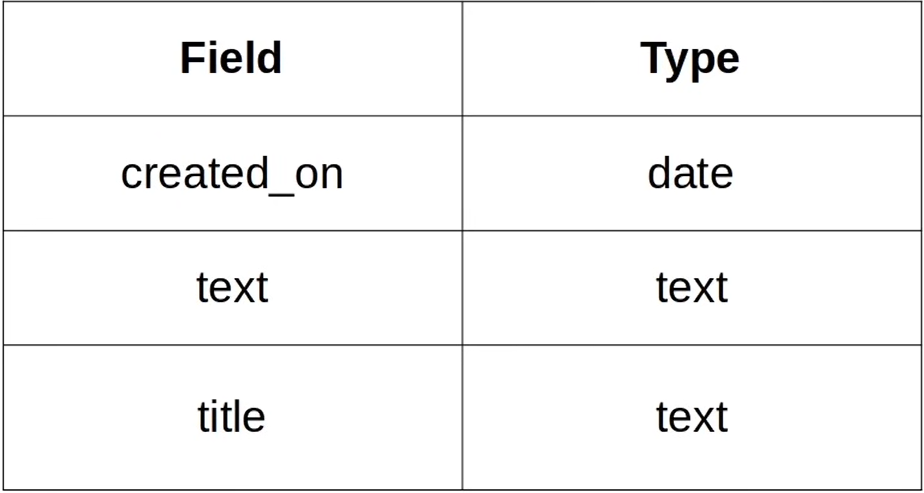

**Note**: all documents have to be in a JSON format and with the same fields in order to add them to the index.

### adding an example document to the index

In [4]:

doc = {
    'title': 'Elasticsearch Basics',
    'text': 'This is a basic introduction to Elasticsearch.',
    'created_on': '2024-06-01'
}

response = es.index(index=index_name, body=doc)
print("Document indexed:", response['result'])

Document indexed: created


In [5]:
# printing other information about the indexed document
print("Document ID:", response['_id'])
print("Index:", response['_index'])
print("Shards:", response['_shards'])

Document ID: uX5u45wBBpXsQp7PncTu
Index: my_index
Shards: {'total': 3, 'successful': 1, 'failed': 0}


### Insertinng multiple documents

In [6]:

docs = [
    {'title': 'Elasticsearch Advanced', 'text': 'This is an advanced guide to Elasticsearch.', 'created_on': '2024-06-02'},
    {'title': 'Elasticsearch Querying', 'text': 'Learn how to query Elasticsearch effectively.', 'created_on': '2024-06-03'},
    {'title': 'Elasticsearch Scaling', 'text': 'Best practices for scaling Elasticsearch clusters.', 'created_on': '2024-06-04'}
]

# define functions
def insert_document(document):
    response = es.index(index=index_name, body=document)
    return response

def print_info(response):
    print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
    

# insert documents and print info
for doc in docs:
    response = insert_document(doc)
    print_info(response)


Document ID: un5u45wBBpXsQp7PoMSA is created in index: my_index and is split into 3 shards.
Document ID: u35u45wBBpXsQp7PoMSY is created in index: my_index and is split into 3 shards.
Document ID: vH5u45wBBpXsQp7PoMS3 is created in index: my_index and is split into 3 shards.


In [7]:
# Showing the elasticsearch mapping
mapping = es.indices.get_mapping(index=index_name)
pprint(mapping[index_name]['mappings']['properties'])

{'created_on': {'type': 'date'},
 'text': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
          'type': 'text'},
 'title': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
           'type': 'text'}}


### Manual mapping

In [8]:
mapping = {
    "properties": {
        "title": {"type": "text",
            'fields': {
                'keyword': {
                    'type': 'keyword',
                    'ignore_above': 256
                    }
            }},
        "text": {"type": "text",
                 'fields': {
                     'keyword': {
                            'type': 'keyword',
                            'ignore_above': 256
                         }
                 }},
        "created_on": {"type": "date"}
    }
}

es.indices.put_mapping(index=index_name, body=mapping)
mapping = es.indices.get_mapping(index=index_name)
pprint(mapping[index_name]['mappings']['properties'])

{'created_on': {'type': 'date'},
 'text': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
          'type': 'text'},
 'title': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
           'type': 'text'}}


## 5. Field Data Types

#### Common Data Types:
* **Binary**: accepts binary values as Base64 encoded string. Not searchable and not stored (Base64 is expensive to store). To get the binary value, we use the '_source' key. (Ex. Images)
* **Boolean**: True/False.
* **Numbers**: long, integer, byte, short, etc.
* **Dates**.
* **Keyword**: IDs, email addresses, status codes, zip codes, etc.

#### Object Data Types (JSON Format):
* **Object**
**Note**: Indexation of object:
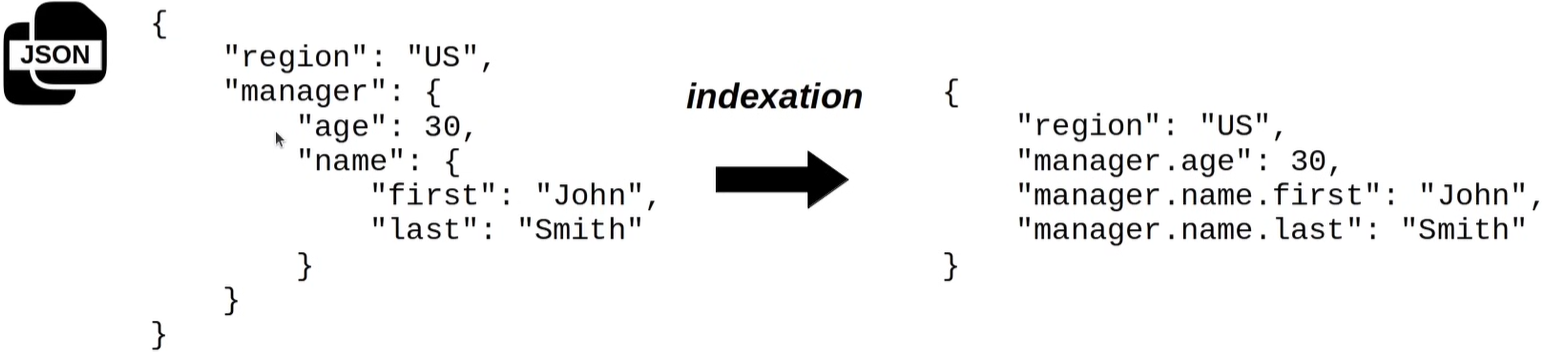

* **Flattened**: Efficient for deeply nested JSON objects. Hierarchical structure not preserved.

* **Nested**: used when we have an array of objects, maintains relationship between the object fields.

**Ex. Flattened**: note that the first name and last names aren't aligned anymore after indexation!
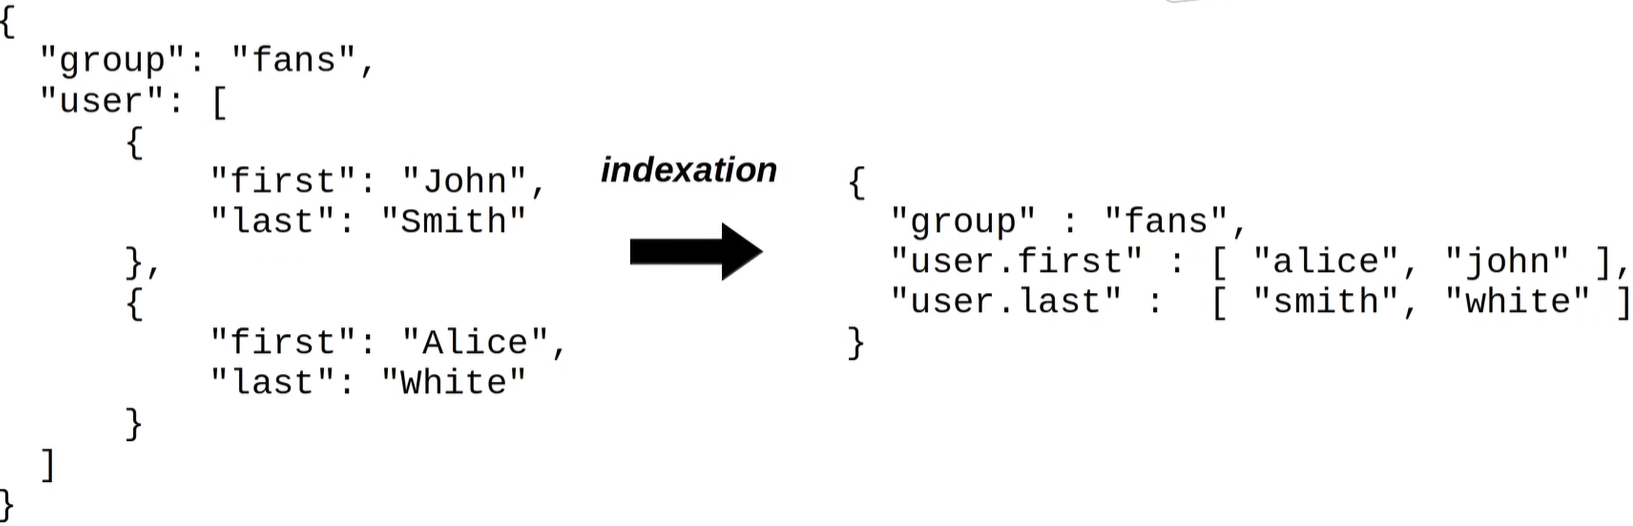

**Ex. Nested**: first and last name would be aligned.


#### Text Search Types:

* **Text**: full-text content. Elasticsearch will attempt to analyze the document in order to optimize the search.
* **Completion**.
* **Search as you type**.
* **Annotated text**.


#### Spatial Data Types:
* **Geo point**: storing the latitude and longtitude of a point.
* **Geo shape**: used to store complex shapes (stores a list of points - needs to be a closed shape so starting point is the same as ending point): 
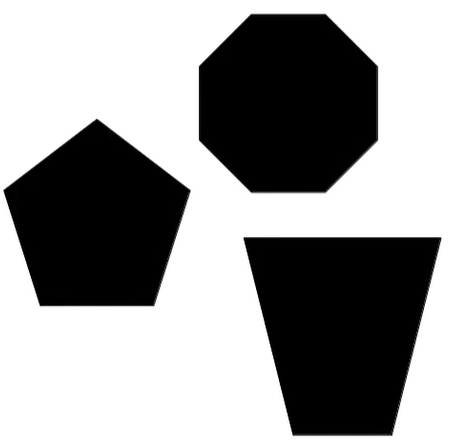
* **Point**: Cartesian point.
* **Shape**: Cartesian geometry.

### Example: Binary

In [9]:
# binary index
# check if already exists and if so, delete it
if es.indices.exists(index="binary_index"):
    es.indices.delete(index="binary_index")
    print("Index 'binary_index' deleted.")
es.indices.create(index="binary_index", body={
    "mappings": {
        "properties": {
            "data": {
                "type": "binary"
            }
        }
    }
})
print("Binary index 'binary_index' created.")

# prepare binary document - image
img_path = "Stray-Kids-Logo.png"
with open(img_path, "rb") as f:  
    img_data = f.read()
    # base 64 encode the binary data
    encoded_data = base64.b64encode(img_data).decode('utf-8')
    print("Binary data encoded to base64: ", encoded_data[:100], "...")  # print the first 100 characters of the encoded data


# Insert document into index
binary_doc = {
    "data": encoded_data
}
response = es.index(index="binary_index", body=binary_doc)
print("Binary document indexed:", response['result'])

Index 'binary_index' deleted.
Binary index 'binary_index' created.
Binary data encoded to base64:  iVBORw0KGgoAAAANSUhEUgAADwAAAAlgCAMAAAACwTJvAAAAS1BMVEVHcEwAAAAAAAAAAAAAAAAAAAAJAQI0BwwBAAAzBwwAAAAA ...
Binary document indexed: created


### Example: Object Type

In [10]:
# checking if object index exists, and if so, delete it
if es.indices.exists(index="object_index"):
    es.indices.delete(index="object_index")
    print("Index 'object_index' deleted.")

# creating an index
index_name = "object_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "author": {  # custom object field
            "properties": {
                "first name": {"type": "text"},
                "last name": {"type": "text"}
            }
        }
    }
}) 


# creating a document with an object field
object_doc = {
    "author": {
        "first name": "John",
        "last name": "Doe"
    }
}

# Insert object document into index
response = es.index(index=index_name, body=object_doc)
print("Object document indexed:", response['result'])

Index 'object_index' deleted.
Object document indexed: created


In [11]:
# print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: the 'author' object field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.")

Document ID: vn5u45wBBpXsQp7Pq8RL is created in index: object_index and is split into 2 shards.
Note: the 'author' object field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.


### Example: Flattened Type

In [12]:
# checking if flattened index exists, and if so, delete it
if es.indices.exists(index="flattened_index"):
    es.indices.delete(index="flattened_index")
    print("Index 'flattened_index' deleted.")

# creating an index
index_name = "flattened_index"  
es.indices.create(index=index_name, mappings={
    "properties": {
        "author": {  # flattened field
            "type": "flattened"
        }
    }
})

# Creating a document with a flattened field
flattened_doc = {
    "author": {
        "first name": "Jane",
        "last name": "Smith"
    }
}

# Insert flattened document into index
response = es.index(index=index_name, body=flattened_doc)
print("Flattened document indexed:", response['result'])

Index 'flattened_index' deleted.
Flattened document indexed: created


In [13]:
# print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'author' field is indexed as a single flattened field, so we cannot query individual subfields like 'first name' or 'last name' directly.")

Document ID: v35u45wBBpXsQp7PrcTK is created in index: flattened_index and is split into 2 shards.
Note: The 'author' field is indexed as a single flattened field, so we cannot query individual subfields like 'first name' or 'last name' directly.


### Example: Nested Type

In [14]:
# checking if nested index exists, and if so, delete it
if es.indices.exists(index="nested_index"):
    es.indices.delete(index="nested_index")
    print("Index 'nested_index' deleted.")

# creating an index
index_name = "nested_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "author": {  # nested field
            "type": "nested"
        }
    }
})

# Creating a document with a nested field (with an array of objects to demonstrate the nested structure)
nested_doc = {
    "author": [
        {
            "first name": "Jane",
            "last name": "Smith"
        },
        {
            "first name": "John",
            "last name": "Doe"
        }
    ]
}

# Insert nested document into index
response = es.index(index=index_name, body=nested_doc)
print("Nested document indexed:", response['result'])

Index 'nested_index' deleted.
Nested document indexed: created


In [15]:
# print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: the 'author' nested field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.")

Document ID: wH5u45wBBpXsQp7PsMSA is created in index: nested_index and is split into 2 shards.
Note: the 'author' nested field allows us to query individual subfields like 'first name' or 'last name' directly, unlike the flattened field where all data is indexed as a single string.


### Example: Text Type

In [16]:
## check if text indice exists, and if so, delete it
if es.indices.exists(index="text_index"):
    es.indices.delete(index="text_index")
    print("Index 'text_index' deleted.")

# creating an index
index_name = "text_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "email_body": { 
            "type": "text"
        }
    }
})

# Creating a document with a text field
text_doc = {
    "email_body": "This is the body of the email."
}

# Insert text document into index
response = es.index(index=index_name, body=text_doc)
print("Text document indexed:", response['result'])

Index 'text_index' deleted.
Text document indexed: created


In [17]:
# print more properties 
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'email_body' text field is analyzed and tokenized, allowing for full-text search capabilities")

Document ID: wX5u45wBBpXsQp7Ps8TF is created in index: text_index and is split into 2 shards.
Note: The 'email_body' text field is analyzed and tokenized, allowing for full-text search capabilities


### Example: Completion Type

In [18]:
## check if completion indice exists, and if so, delete it
if es.indices.exists(index="completion_index"):
    es.indices.delete(index="completion_index")
    print("Index 'completion_index' deleted.")

# creating an index
index_name = "completion_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "suggest": { 
            "type": "completion"
        }
    }
})

# Creating a document with a completion field
completion_doc1 = {
    "suggest": {
        "input": ["Mars", "Planet"]
    }
}

completion_doc2 = {
    "suggest": {
        "input": ["Andromeda", "Galaxy"]
    }
}

# Insert completion documents into index
response = es.index(index=index_name, body=completion_doc1)
print("Completion document indexed:", response['result'])

response = es.index(index=index_name, body=completion_doc2)
print("Completion document indexed:", response['result'])

Index 'completion_index' deleted.
Completion document indexed: created
Completion document indexed: created


In [19]:
# print more properties 
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'suggest' completion field allows for efficient auto-complete and suggestion features, as it is optimized for prefix queries and can provide real-time suggestions based on the indexed input.")

# example of a search query for the completion field
suggest_query = {
    "suggest": {
        "my_suggest": {
            "prefix": "Mar",
            "completion": {
                "field": "suggest"
            }
        }
    }
}
response = es.search(index=index_name, body=suggest_query)
print(f"Completion suggestions for prefix 'Mar': {response['suggest']['my_suggest'][0]['options']}")

Document ID: w35u45wBBpXsQp7PtsSy is created in index: completion_index and is split into 2 shards.
Note: The 'suggest' completion field allows for efficient auto-complete and suggestion features, as it is optimized for prefix queries and can provide real-time suggestions based on the indexed input.
Completion suggestions for prefix 'Mar': []


### Example: Geo point Type

In [20]:
# check if geopoint index exists, and if so, delete it
if es.indices.exists(index="geopoint_index"):
    es.indices.delete(index="geopoint_index")
    print("Index 'geopoint_index' deleted.")

# creating an index
index_name = "geopoint_index"
es.indices.create(index=index_name, mappings={
    "properties": {
        "location": { 
            "type": "geo_point"
        }
    }
})

# Creating a document with a geo_point field
geo_doc = {
    "text": "Geopoint is an objet using GeoJSON format",
    "location": {
        "type": "Point",
        "coordinates": [
            -73.935242, # longitude
            40.730610   # latitude
            ]  
    }
}

# Insert geo document into index
response = es.index(index=index_name, body=geo_doc)
print("Geo document indexed:", response['result'])

Index 'geopoint_index' deleted.
Geo document indexed: created


In [21]:
#print more properties
print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
print("Note: The 'location' geo_point field allows for geospatial queries, such as finding documents within a certain distance from a point or within a bounding box, making it ideal for location-based applications.")

Document ID: xH5u45wBBpXsQp7PucTV is created in index: geopoint_index and is split into 2 shards.
Note: The 'location' geo_point field allows for geospatial queries, such as finding documents within a certain distance from a point or within a bounding box, making it ideal for location-based applications.


## 6. Delete Documents

In [30]:
index_name = "delete_test_index"
create_dummy_index(index_name)
# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# seeing how many docs we have in the index before deletion
count_response = es.count(index=index_name)
print(f"Total documents in index before deletion: {count_response['count']}")

# get document id of the first document
search_response = es.search(index=index_name, body={"query": {"match_all": {}}})
first_doc_id = search_response['hits']['hits'][0]['_id']


# deleting the first document
es.delete(index=index_name, id=first_doc_id)
print(f"Document with ID: {first_doc_id} deleted.")

# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# showing there are now 2 docs instead of 3
count_response = es.count(index=index_name)
print(f"Total documents in index after deletion: {count_response['count']}")

Index 'delete_test_index' deleted.
Document indexed with ID: 135645wBBpXsQp7PQsSe and result: created
Document indexed with ID: 2H5645wBBpXsQp7PQsSu and result: created
Document indexed with ID: 2X5645wBBpXsQp7PQsS5 and result: created
Total documents in index before deletion: 3
Document with ID: 135645wBBpXsQp7PQsSe deleted.
Total documents in index after deletion: 2


## 7. Get Documents

In [31]:
index_name = "get_query_test_index"
create_dummy_index(index_name)

# force Elasticsearch to refresh the index (so we can immidiatly see the changes in the next search query)
es.indices.refresh(index=index_name)

# get document id of the first document
search_response = es.search(index=index_name, body={"query": {"match_all": {}}})
first_doc_id = search_response['hits']['hits'][0]['_id']

# get the first document using its id
get_response = es.get(index=index_name, id=first_doc_id)
print(f"Document with ID: {first_doc_id} retrieved. Source: {get_response['_source']}")

Document indexed with ID: 2n5645wBBpXsQp7PUcTa and result: created
Document indexed with ID: 235645wBBpXsQp7PUcTs and result: created
Document indexed with ID: 3H5645wBBpXsQp7PUcT4 and result: created
Document with ID: 2n5645wBBpXsQp7PUcTa retrieved. Source: {'field1': 'This is the first document.', 'field2': 'A'}
